# Customer Churn Model Prediction Pipeline
**Goal:** Predict whether the customer will churn (`Yes`/`No`) using full pipelines.

## 1. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## 2. Load data

In [2]:
df=pd.read_csv(r'C:\Users\user\Desktop\Karan\DATA SCIENCE\DataSets\Customer Churn\Telco-Customer-Churn.csv')
df.columns, df.shape

(Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
        'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
       dtype='object'),
 (7043, 21))

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Performing EDA

### 3.1 Data Types and Missing Values

In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
#TotalCharges is dtype object - coercing to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()[df.isnull().sum() > 0]

TotalCharges    11
dtype: int64

### 3.2 Statistical Brief

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80


### 3.3 Churn Distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn Rate: 26.54%


Text(0.5, 1.0, 'Churn Proportion')

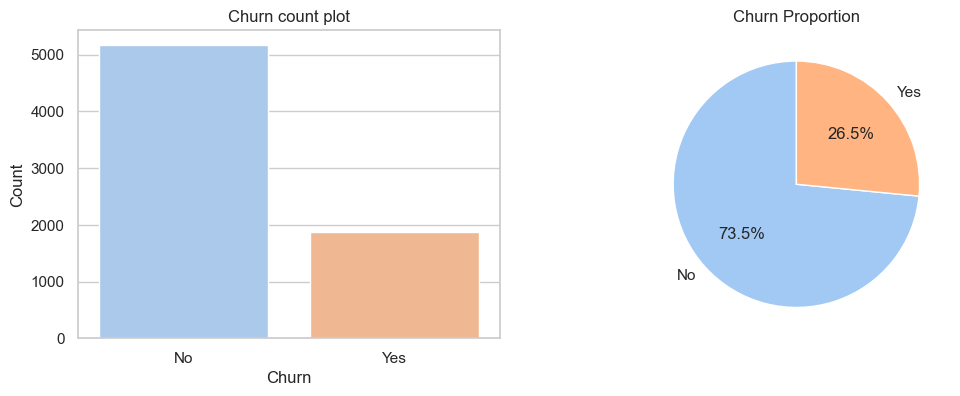

In [7]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print('Churn Rate: {}%'.format((churn_counts['Yes'] / len(df) *100).round(2)))

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Churn count plot
sns.countplot(data=df, x='Churn', ax=axes[0], palette='pastel', hue='Churn')
axes[0].set_title('Churn count plot')
axes[0].set_ylabel('Count')

# Pie Chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_title('Churn Proportion')

### 3.4 Numerical feature Distribution by Churn

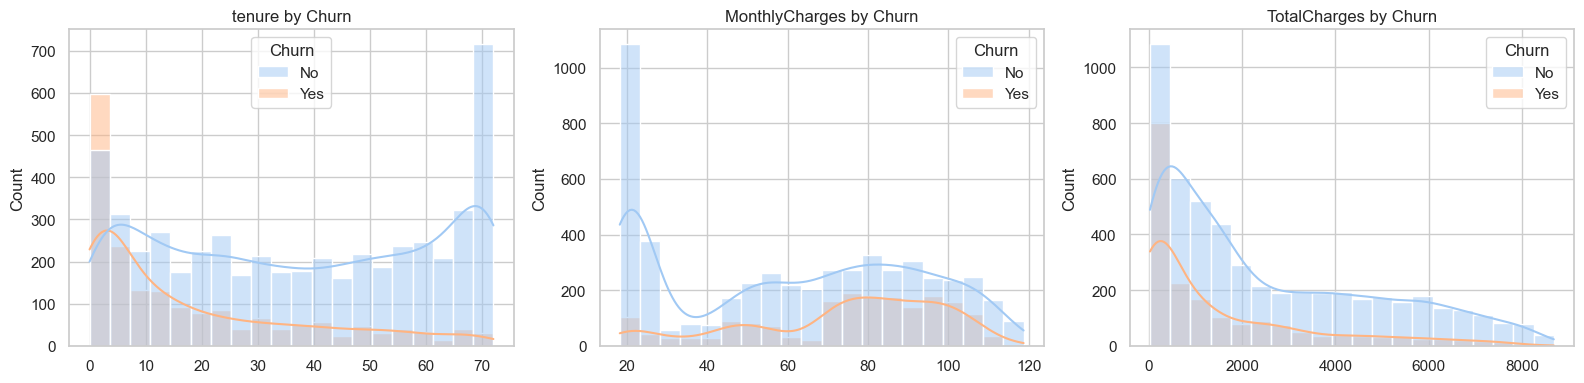

In [8]:
fig, axes = plt.subplots(1,3 , figsize=(16,4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', ax=ax, palette='pastel', kde=True, bins=20)
    ax.set_title('{} by Churn'.format(col))
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 3.5 Categorical features vs Churn

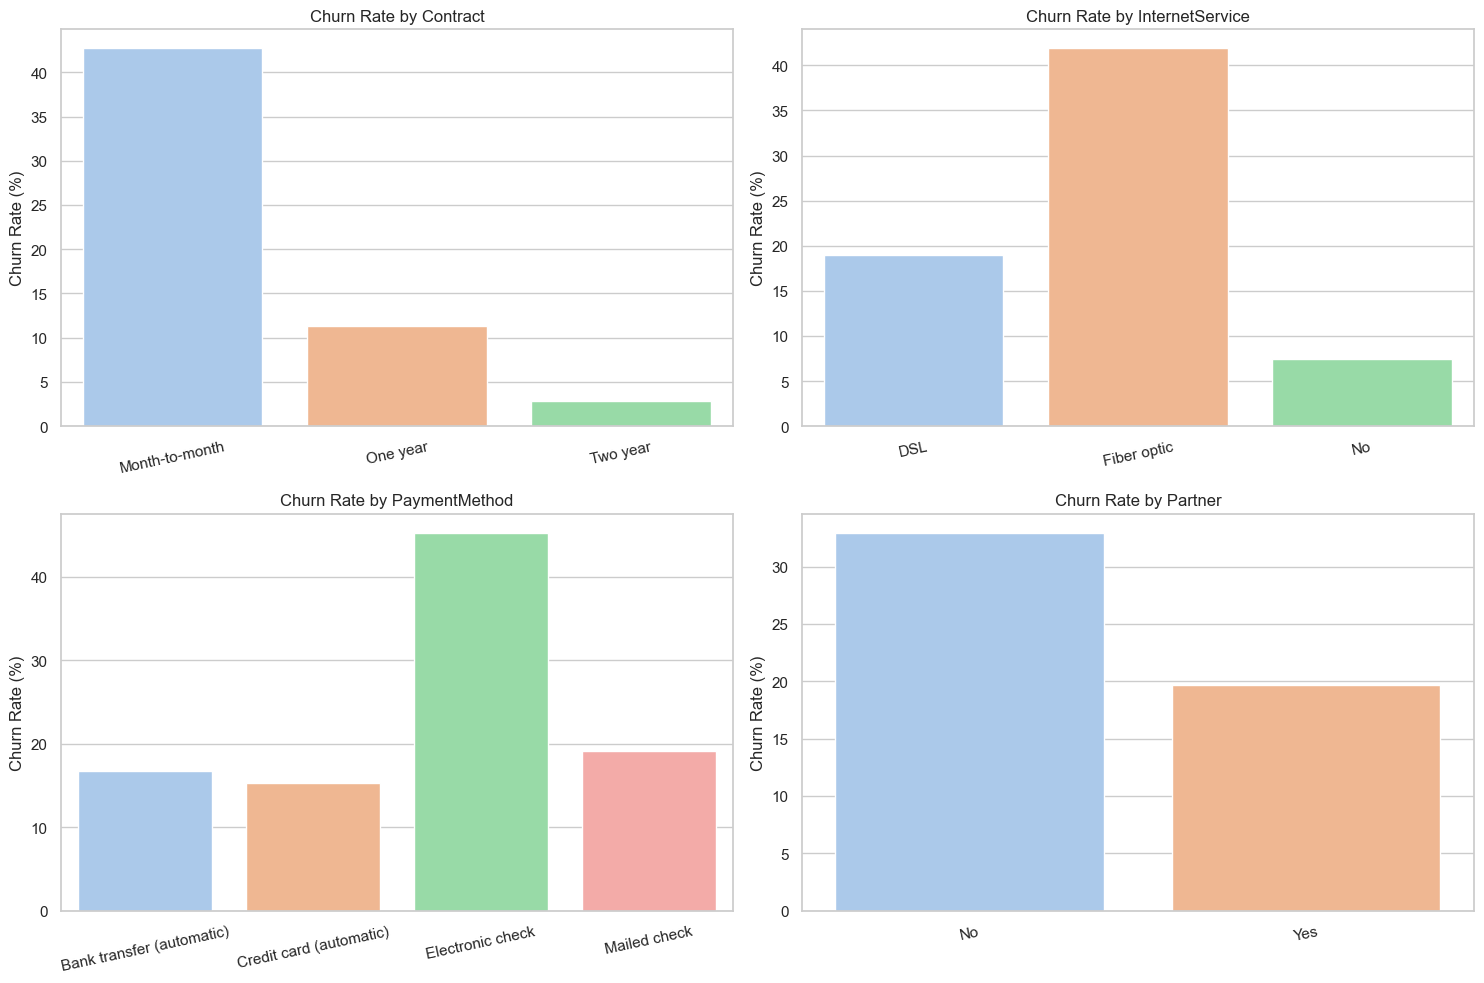

In [9]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'Partner']
fig, axes = plt.subplots(2, 2, figsize=(15,10))

for ax, col in zip(axes.flatten(), cat_features):
    churn_pct = (df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name = 'Churn Rate (%)'))
    sns.barplot(data=churn_pct, x=col, y='Churn Rate (%)', ax=ax, palette='pastel', hue=col)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap

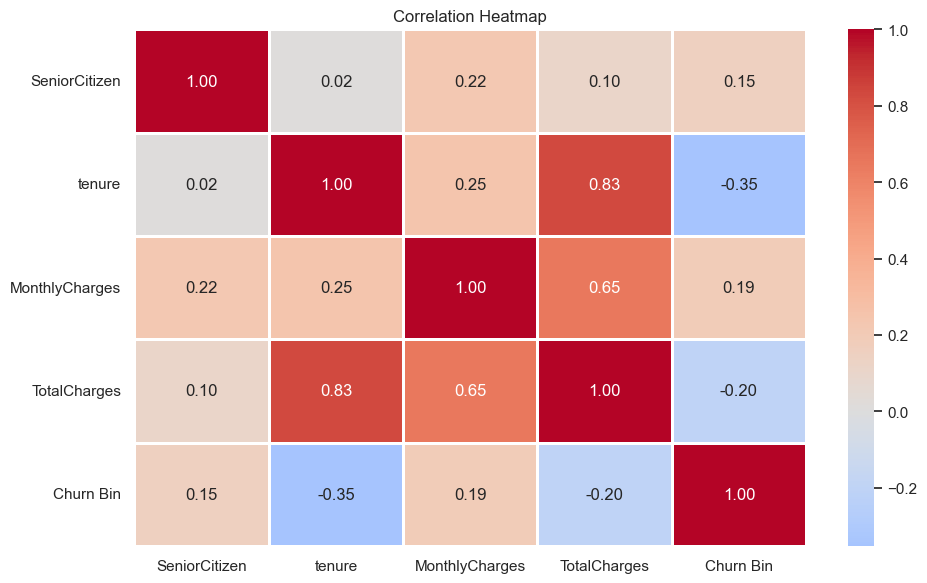

In [10]:
temp_df = df.copy()
temp_df['Churn Bin'] = (temp_df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(10,6))
sns.heatmap(temp_df.corr(numeric_only = True), annot = True, fmt='.2f', cmap = 'coolwarm', center = 0, linewidth =2)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 3.7 Boxplot by Contract type

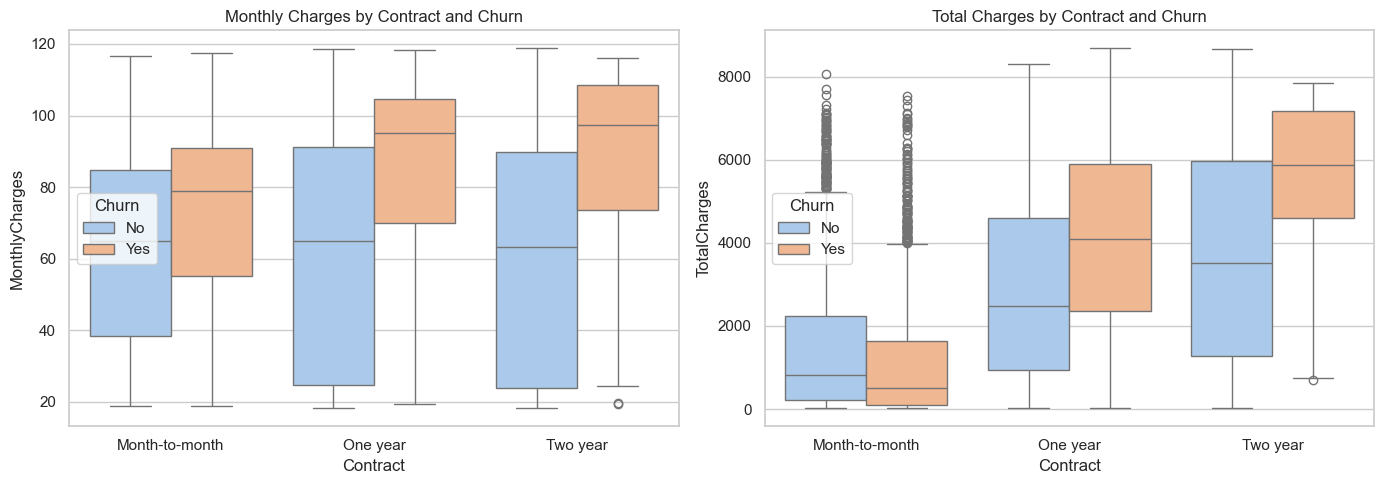

In [11]:
fig, axes = plt.subplots(1,2, figsize = (14,5))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', ax=axes[0], palette='pastel')
axes[0].set_title('Monthly Charges by Contract and Churn')
sns.boxplot(data=df, x='Contract', y='TotalCharges', hue='Churn', ax=axes[1], palette='pastel')
axes[1].set_title('Total Charges by Contract and Churn')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [12]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
from sklearn.preprocessing import LabelEncoder

fe_df = df.copy()

# Dropping CustomerID due to it being an identifier
fe_df = fe_df.drop('customerID', axis=1)

# Imputing missing Total Charges with median
fe_df['TotalCharges'] = fe_df['TotalCharges'].fillna(fe_df['TotalCharges'].median())

# Derived numeric features
fe_df['AvgMonthlySpend'] = fe_df['TotalCharges'] / (fe_df['tenure'] + 1)
fe_df['NumAddOns'] = (
    (fe_df['OnlineSecurity'] == 'Yes').astype(int) + 
    (fe_df['OnlineBackup'] == 'Yes').astype(int) + 
    (fe_df['DeviceProtection'] == 'Yes').astype(int) + 
    (fe_df['TechSupport'] == 'Yes').astype(int) + 
    (fe_df['StreamingTV'] == 'Yes').astype(int) + 
    (fe_df['StreamingMovies'] == 'Yes').astype(int)
)

# Binary features
fe_df['HasStreaming'] = ((fe_df['StreamingTV'] == 'Yes') | 
                         (fe_df['StreamingMovies']) == 'Yes').astype(int)
fe_df['HasOnlineServies'] = ((fe_df['OnlineSecurity'] == 'Yes') | 
                            (fe_df['OnlineBackup'] == 'Yes') |
                            (fe_df['DeviceProtection'] == 'Yes') |
                             (fe_df['TechSupport'] == 'Yes')).astype(int)
fe_df['IsMonthToMonth'] = (fe_df['Contract'] == 'Month-To-month').astype(int)
fe_df['HasFiberOptic'] = (fe_df['InternetService'] =='Fiber optic').astype(int)
fe_df['IsElectronicCheck'] = (fe_df['PaymentMethod'] == 'Electronic check').astype(int)

# Tenure bucket
fe_df['TenureGroup'] = pd.cut(fe_df['tenure'],
                               bins=[0, 12, 24, 48, 72],
                               labels=['0-12m', '13-24m', '25-48m', '49-72m'])

# Encoding target label
fe_df['Churn'] = (fe_df['Churn'] == 'Yes').astype(int)

# Label Encode remaining categoricals
cat_cols = fe_df.select_dtypes(include =['object', 'category']).columns.tolist()
le = LabelEncoder()
for cols in cat_cols:
    fe_df[cols] = le.fit_transform(fe_df[cols].astype(str))

print('Final Shape:',fe_df.shape)
fe_df.head()

Final Shape: (7043, 28)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,AvgMonthlySpend,NumAddOns,HasStreaming,HasOnlineServies,IsMonthToMonth,HasFiberOptic,IsElectronicCheck,TenureGroup
0,0,0,1,0,1,0,1,0,0,2,...,29.85,0,14.925000,1,0,1,0,0,1,0
1,1,0,0,0,34,1,0,0,2,0,...,1889.50,0,53.985714,2,0,1,0,0,0,2
2,1,0,0,0,2,1,0,0,2,2,...,108.15,1,36.050000,2,0,1,0,0,0,0
3,1,0,0,0,45,0,1,0,2,0,...,1840.75,0,40.016304,3,0,1,0,0,0,2
4,0,0,0,0,2,1,0,1,0,0,...,151.65,1,50.550000,0,0,0,0,1,1,0


## 5. Train / Test Split

In [14]:
from sklearn.model_selection import train_test_split

X = fe_df.drop('Churn', axis = 1)
y = fe_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'Train : {X_train.shape[0]} samples with churn rate {(y_train.mean() * 100).round(2)}%')
print(f'Test : {X_test.shape[0]} samples with churn rate {(y_test.mean() * 100).round(2)}%')

Train : 5634 samples with churn rate 26.54%
Test : 1409 samples with churn rate 26.54%


## 6. Preprocessing Pipelines

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
}

pipelines = {
    name: Pipeline([
        ('imputer', SimpleImputer(strategy =  'median')),
        ('scaler', StandardScaler()),
        ('model', clf)
    ])
    for name, clf in models.items()
}

print("Pipelines created for:", list(pipelines.keys()))

Pipelines created for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'SVM', 'KNN']


## 7. Model Training and Comparison

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv_s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'ROC-AUC': auc,
        'CV Mean': cv_s.mean(), 'CV Std': cv_s.std(),
        'y_pred': y_pred, 'y_prob': y_prob,
    }

In [17]:
results_df = pd.DataFrame({
    name: {k: v for k, v in vals.items()
           if k not in ('y_pred', 'y_prob')}
    for name, vals in results.items()
}).T.round(4)

results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,CV Mean,CV Std
Logistic Regression,0.8119,0.6860,0.5374,0.6027,0.8467,0.8488,0.0123
Decision Tree,0.7885,0.6188,0.5294,0.5706,0.8312,0.8221,0.0100
Random Forest,0.7828,0.6126,0.4947,0.5473,0.8216,0.8276,0.0109
AdaBoost,0.8013,0.6546,0.5321,0.5870,0.8450,0.8460,0.0106
SVM,0.7928,0.6454,0.4866,0.5549,0.7852,0.7998,0.0162
KNN,0.7544,0.5422,0.4813,0.5099,0.7830,0.7875,0.0089


## 8. Cross Validation Scores

C:\Users\user\AppData\Local\Temp\ipykernel_12484\4207467842.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cv_data.index, y=cv_data['CV Mean'], palette='dark')


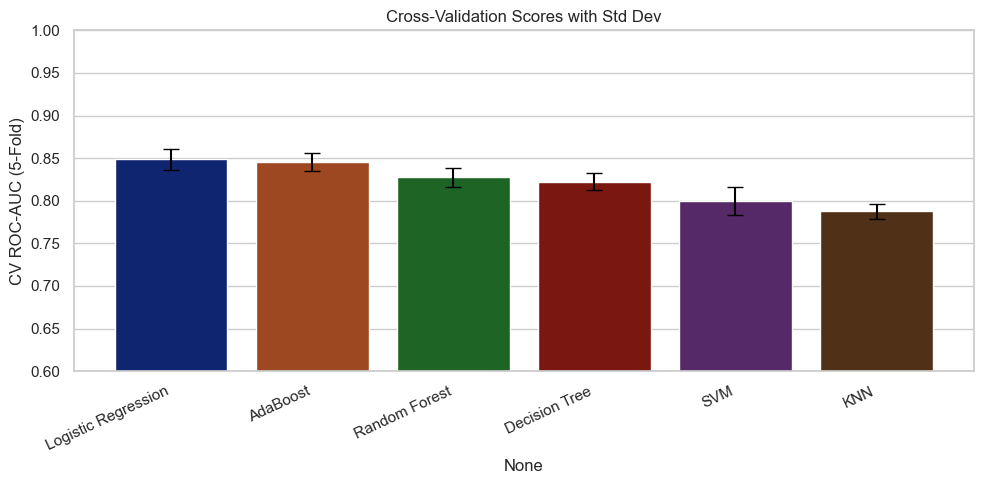

In [18]:
plt.figure(figsize=(10, 5))
cv_data = results_df[['CV Mean', 'CV Std']].sort_values('CV Mean', ascending=False)

sns.barplot(x=cv_data.index, y=cv_data['CV Mean'], palette='dark')
plt.errorbar(x=range(len(cv_data)), y=cv_data['CV Mean'],
             yerr=cv_data['CV Std'], fmt='none', color='black', capsize=6)
plt.xticks(rotation=25, ha='right')
plt.ylim(0.6, 1.0)
plt.ylabel('CV ROC-AUC (5-Fold)')
plt.title('Cross-Validation Scores with Std Dev')
plt.tight_layout()
plt.show()

## 9. Evaluation

### 9.1 Model Comparison - All Metrics

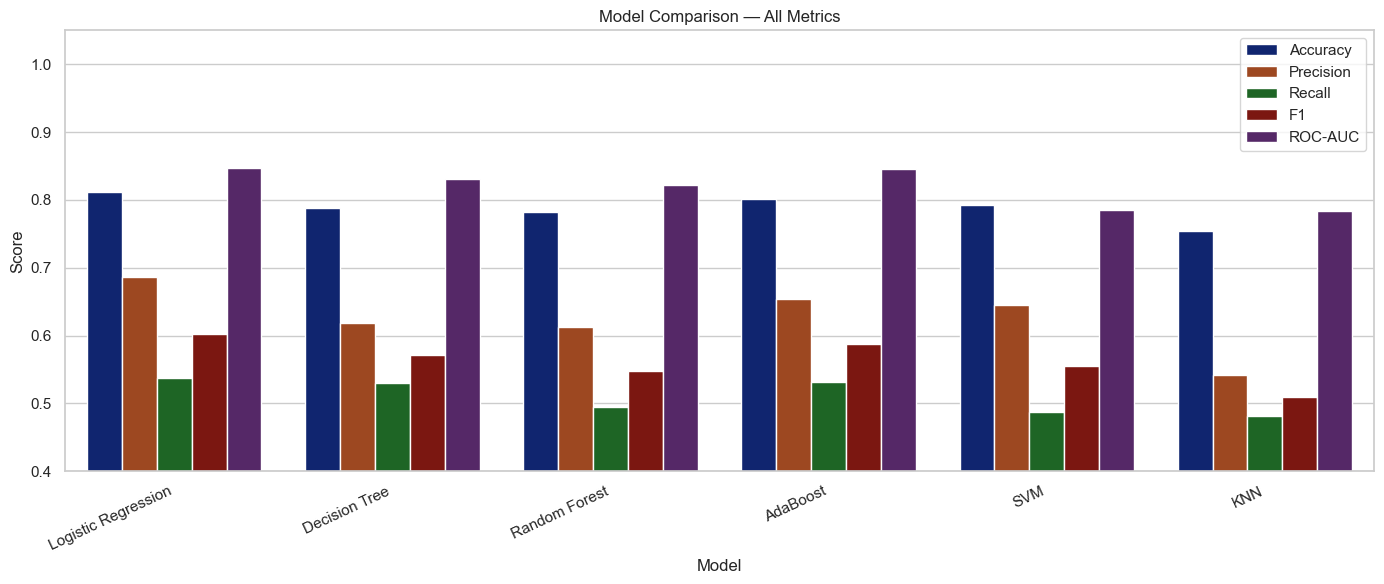

In [19]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
plot_df = results_df[metrics].reset_index().melt(id_vars='index',
                                                  var_name='Metric',
                                                  value_name='Score')
plot_df.rename(columns={'index': 'Model'}, inplace=True)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='dark')
plt.xticks(rotation=25, ha='right')
plt.ylim(0.4, 1.05)
plt.title('Model Comparison — All Metrics')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 9.2 ROC Curves

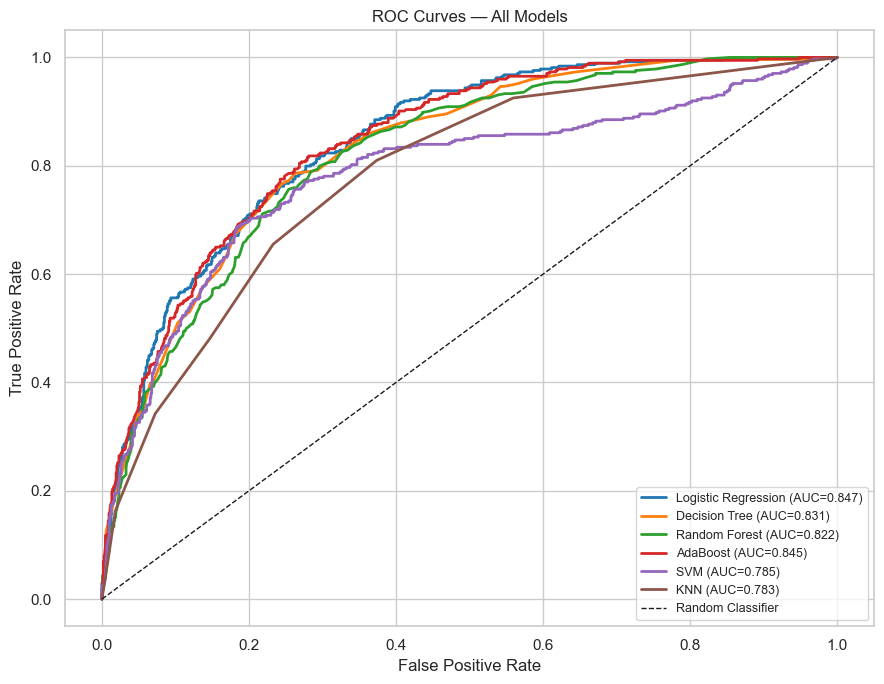

In [20]:
plt.figure(figsize=(9, 7))
palette = sns.color_palette('tab10', len(results))

for (name, vals), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC={vals['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 9.3 Confusion Matrices — Top 4 Models

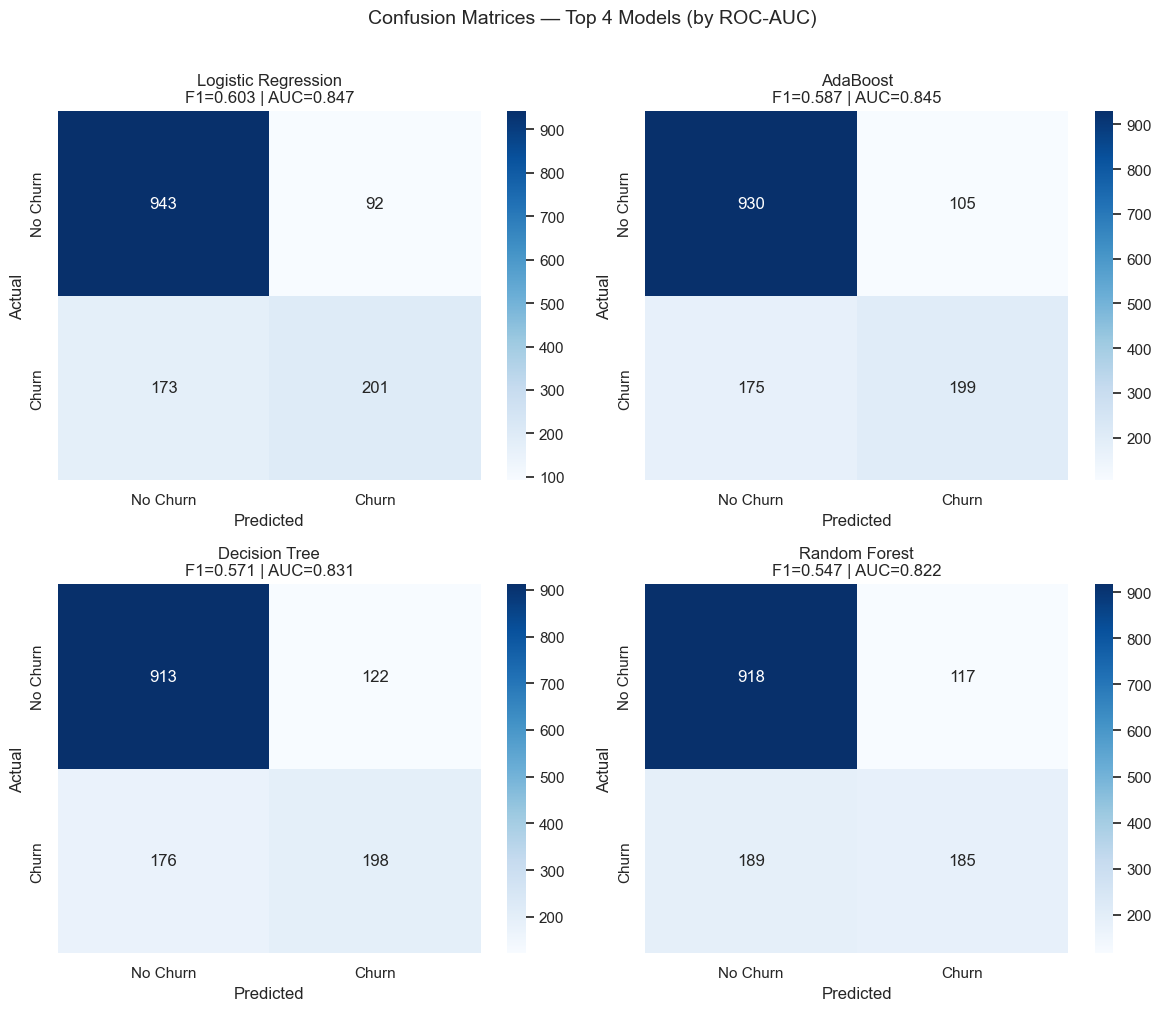

In [21]:
top4 = results_df.nlargest(4, 'ROC-AUC').index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, name in zip(axes.flatten(), top4):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f"{name}\nF1={results[name]['F1']:.3f} | AUC={results[name]['ROC-AUC']:.3f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Top 4 Models (by ROC-AUC)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9.4 Feature Importance — Random Forest

C:\Users\user\AppData\Local\Temp\ipykernel_12484\4252360713.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='dark')


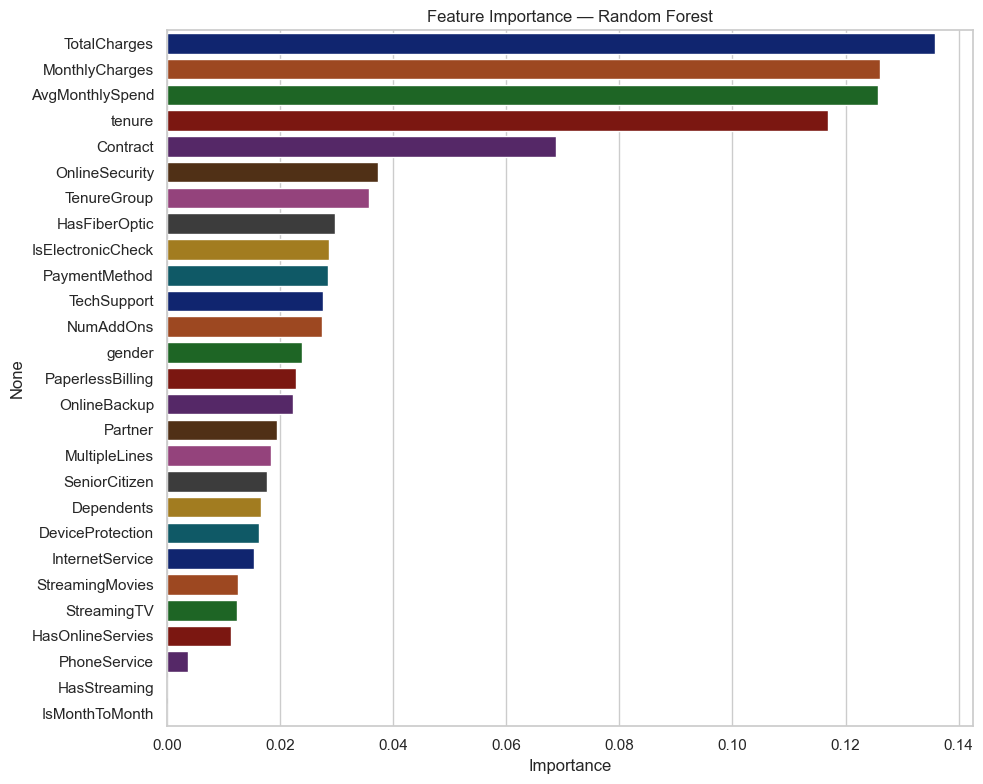

In [22]:
rf_pipe = pipelines['Random Forest']
feat_imp = (pd.Series(rf_pipe.named_steps['model'].feature_importances_,index=X.columns).sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='dark')
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

### 9.5 Best Model — Detailed Classification Report

In [23]:
best_model = results_df['ROC-AUC'].idxmax()
print(f"Best model by ROC-AUC: {best_model} ({results_df.loc[best_model, 'ROC-AUC']:.4f})\n")
print(classification_report(y_test, results[best_model]['y_pred'], target_names=['No Churn', 'Churn']))

Best model by ROC-AUC: Logistic Regression (0.8467)

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.88      1035
       Churn       0.69      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

